# Project 5 — Ensemble Learning: Bagging, Random Forest, AdaBoost, and Gradient Boosting

This notebook compares ensemble strategies: bagging, random forests, AdaBoost, gradient boosting, and optional XGBoost/LightGBM. The goal is to understand how ensembles reduce variance, reduce bias, and trade computation for performance.

## Theoretical background: why ensemble learning works

Ensemble learning combines multiple models to obtain better generalization than a single model. The benefit comes from reducing error through diversity: if different models make different mistakes, combining them can produce a more stable predictor.

**Bagging** trains many models on bootstrap samples and averages their predictions. It mainly reduces variance and is especially effective for unstable learners such as decision trees. **Random Forest** extends bagging by also selecting random subsets of features at each split, which decorrelates trees further. **Extra Trees** add even more randomness by choosing split thresholds more randomly.

**Boosting** is different from bagging. It builds models sequentially so that later learners focus on errors made by earlier learners. **AdaBoost** increases emphasis on previously misclassified samples and is sensitive to noisy labels or outliers. **Gradient Boosting** fits new learners to the residual/error direction of the current ensemble. Methods such as XGBoost and LightGBM are optimized and regularized implementations of gradient boosting.

The main analytical questions are: Does the ensemble reduce variance compared with a single tree? Does boosting reduce bias without overfitting? Do additional estimators still help? Does the performance gain justify the computational cost and reduced interpretability?

## Problem statement

Given a classification task, compare ensemble strategies and understand when bagging or boosting is useful.

## Dataset description and source

The Breast Cancer Wisconsin dataset is loaded directly from `sklearn.datasets.load_breast_cancer`. It is fast enough for repeated ensemble experiments while still being a real tabular dataset.

The notebook begins by importing the scientific Python stack, setting a reproducible random seed, and configuring plots. Keeping these imports together makes the workflow easier to rerun and debug.

In [1]:
# Optional: run this if you want optional boosted libraries.
# !pip install xgboost lightgbm


# Optional: run this only if your environment is missing packages.
# !pip install numpy pandas matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

from sklearn.datasets import load_breast_cancer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.base import clone

The Breast Cancer dataset is loaded directly from scikit-learn. The initial checks show the number of observations, feature columns, target labels, and whether the task is suitable for classification experiments.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
X = df.drop(columns="target")
y = df["target"]
print("Shape:", df.shape)
display(y.value_counts(normalize=True).rename("class_proportion").to_frame())
display(X.describe().T.head())
print("All features are numerical, so preprocessing is simple. A pipeline/ColumnTransformer is still recommended for mixed real-world datasets.")

Shape: (569, 31)


,class_proportion
1,0.627417
0,0.372583


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


All features are numerical, so preprocessing is simple. A pipeline/ColumnTransformer is still recommended for mixed real-world datasets.


### Analytical interpretation

The dataset is clean and compact, which makes it suitable for repeated experiments. The class proportions should be checked before interpreting accuracy because imbalance can make a naive classifier look better than it really is.

## EDA summary

The correlation heatmap summarizes linear associations among features and the target. Strong feature-feature correlations are especially relevant for coefficient interpretation and regularized linear models.

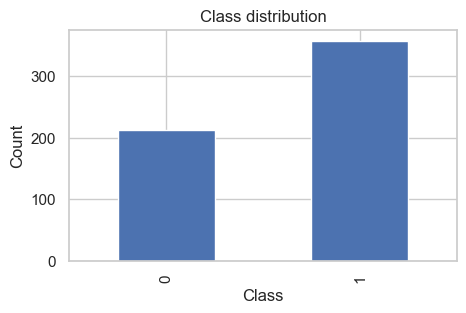

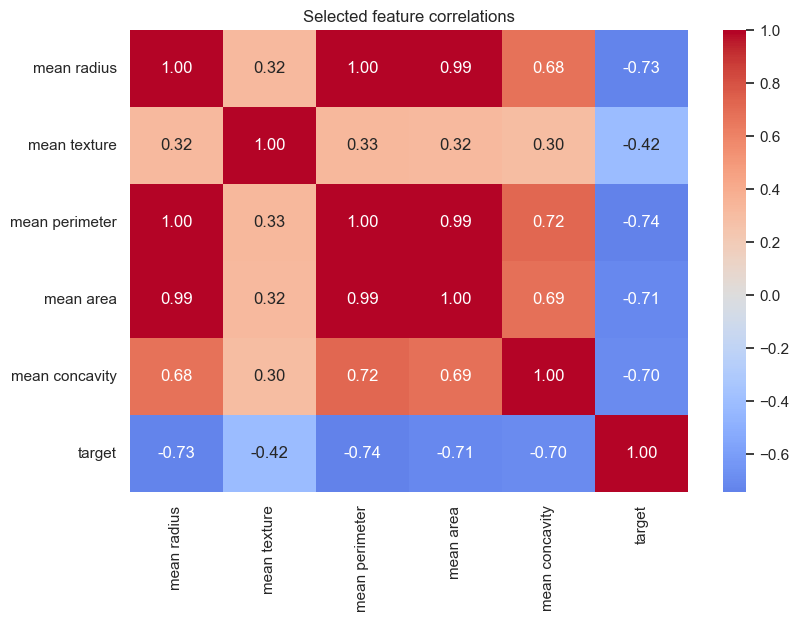

In [3]:
y.value_counts().sort_index().plot(kind="bar", figsize=(5,3), title="Class distribution")
plt.xlabel("Class"); plt.ylabel("Count"); plt.show()
selected = ["mean radius", "mean texture", "mean perimeter", "mean area", "mean concavity"]
plt.figure(figsize=(9,6))
sns.heatmap(df[selected + ["target"]].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Selected feature correlations")
plt.show()

### Analytical interpretation

The heatmap helps identify redundant predictors and strong linear associations. When predictors are correlated, coefficient-based interpretation becomes less direct because multiple variables may share the same explanatory signal.

## Train/validation/test split

The data are split into separate partitions so that model selection and final evaluation remain distinct. This separation prevents the test set from influencing hyperparameter choices.

In [4]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)
print(X_train.shape, X_val.shape, X_test.shape)

(341, 30) (114, 30) (114, 30)


### Analytical interpretation

The split sizes confirm that training, validation, and testing are separated. The validation set supports model selection, while the final test set should be used only after the modeling decisions are fixed.

This cell varies the decision threshold and records how the error trade-off changes. The purpose is to choose a threshold based on the objective, not to assume that 0.5 is always appropriate.

In [5]:
def binary_metrics(y_true, y_pred, y_score=None):
    out = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        out["ROC_AUC"] = roc_auc_score(y_true, y_score)
        out["PR_AUC"] = average_precision_score(y_true, y_score)
    return out

def get_positive_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return scores
    return None

def evaluate_binary_model(name, model, X_train, y_train, X_val, y_val, threshold=0.5, fit=True):
    start = time.time()
    if fit:
        model.fit(X_train, y_train)
    runtime = time.time() - start
    val_score = get_positive_scores(model, X_val)
    if val_score is not None and hasattr(model, "predict_proba"):
        val_pred = (val_score >= threshold).astype(int)
    else:
        val_pred = model.predict(X_val)
    row = {"Model": name, "Threshold": threshold, "Runtime_sec": runtime}
    row.update(binary_metrics(y_val, val_pred, val_score))
    return row

## Single Decision Tree baseline

A shallow tree has high bias. A deep tree can have high variance. Ensembles often improve by combining many imperfect trees.

Tree complexity is varied manually through depth or leaf-size parameters. Comparing training and validation scores shows whether the tree is too simple, reasonably balanced, or overfitting.

In [6]:
tree_configs = {
    "Shallow tree depth=2": DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
    "Deep tree": DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE),
}
rows=[]
for name, model in tree_configs.items():
    model.fit(X_train, y_train)
    rows.append({"Model": name, "train_F1": f1_score(y_train, model.predict(X_train)), "val_F1": f1_score(y_val, model.predict(X_val)), "val_accuracy": accuracy_score(y_val, model.predict(X_val))})
display(pd.DataFrame(rows))

,Model,train_F1,val_F1,val_accuracy
0,Shallow tree depth=2,0.974478,0.958333,0.947368
1,Deep tree,1.000000,0.964029,0.956140


### Analytical interpretation

The tree experiments should show the classic complexity pattern: shallow trees underfit, while very deep trees often achieve high training performance with weaker validation behavior. Leaf-size constraints usually improve stability by preventing tiny, highly specific terminal regions.

## Bagging Classifier

Bagging trains many trees on bootstrap samples and averages/votes their predictions. It mainly reduces variance.

Bagging trains multiple models on bootstrap samples and aggregates their predictions. Since each tree sees a slightly different dataset, their errors are not perfectly identical. Averaging those predictions reduces variance.

Tree complexity is varied manually through depth or leaf-size parameters. Comparing training and validation scores shows whether the tree is too simple, reasonably balanced, or overfitting.

In [7]:
def make_bagging(n_estimators=50, max_samples=1.0):
    base_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
    try:
        return BaggingClassifier(estimator=base_tree, n_estimators=n_estimators, max_samples=max_samples, random_state=RANDOM_STATE, n_jobs=-1)
    except TypeError:
        return BaggingClassifier(base_estimator=base_tree, n_estimators=n_estimators, max_samples=max_samples, random_state=RANDOM_STATE, n_jobs=-1)

bag_rows=[]
for n in [10, 50, 100, 200]:
    model = make_bagging(n_estimators=n, max_samples=1.0)
    row = evaluate_binary_model(f"Bagging n={n}", model, X_train, y_train, X_val, y_val)
    row["n_estimators"] = n
    bag_rows.append(row)
for ms in [0.5, 0.7, 1.0]:
    model = make_bagging(n_estimators=100, max_samples=ms)
    row = evaluate_binary_model(f"Bagging max_samples={ms}", model, X_train, y_train, X_val, y_val)
    row["max_samples"] = ms
    bag_rows.append(row)
bag_df = pd.DataFrame(bag_rows)
display(bag_df[["Model", "Accuracy", "F1", "ROC_AUC", "Runtime_sec"]])

,Model,Accuracy,F1,ROC_AUC,Runtime_sec
0,Bagging n=10,0.938596,0.951724,0.971831,4.173498
1,Bagging n=50,0.947368,0.958333,0.976744,0.302208
2,Bagging n=100,0.938596,0.951049,0.985588,0.529150
3,Bagging n=200,0.938596,0.951049,0.983131,1.048858
4,Bagging max_samples=0.5,0.938596,0.951049,0.986079,0.332577
5,Bagging max_samples=0.7,0.938596,0.951049,0.976089,0.382031
6,Bagging max_samples=1.0,0.938596,0.951049,0.985588,0.486550


### Analytical interpretation

The tree experiments should show the classic complexity pattern: shallow trees underfit, while very deep trees often achieve high training performance with weaker validation behavior. Leaf-size constraints usually improve stability by preventing tiny, highly specific terminal regions.

## Random Forest

Random forests add feature randomness to bagging. `n_estimators`, `max_depth`, `max_features`, and `min_samples_leaf` affect variance, bias, and runtime.

Random Forests reduce the variance of individual decision trees by averaging many decorrelated trees. They often perform well with limited tuning, but depth, feature subsampling, and leaf size still shape the bias-variance trade-off.

Random Forest settings are varied to study variance reduction, tree complexity, and runtime. The important pattern is whether performance stabilizes as more trees are added.

,n_estimators,Accuracy,Precision,Recall,F1,ROC_AUC,Runtime_sec
0,10,0.947368,0.945205,0.971831,0.958333,0.971340,0.041275
1,50,0.947368,0.945205,0.971831,0.958333,0.983295,0.173874
2,100,0.956140,0.958333,0.971831,0.965035,0.983786,0.262777
3,200,0.956140,0.958333,0.971831,0.965035,0.980347,0.467069


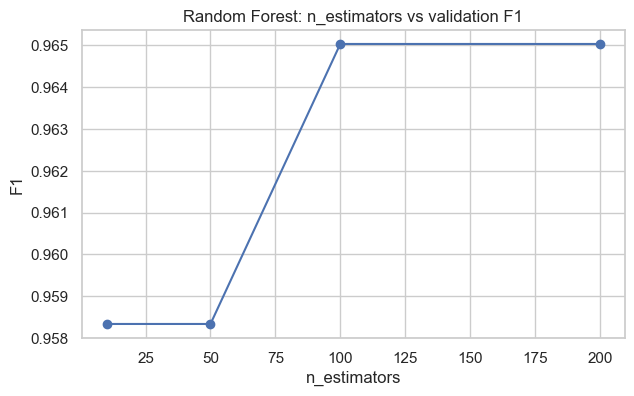


 max_depth


,max_depth,Accuracy,Precision,Recall,F1,ROC_AUC
0,3,0.956140,0.958333,0.971831,0.965035,0.985588
1,5,0.947368,0.957746,0.957746,0.957746,0.984933
2,10,0.956140,0.958333,0.971831,0.965035,0.983786
3,None,0.956140,0.958333,0.971831,0.965035,0.983786



 max_features


,max_features,Accuracy,Precision,Recall,F1,ROC_AUC
0,sqrt,0.956140,0.958333,0.971831,0.965035,0.983786
1,log2,0.956140,0.958333,0.971831,0.965035,0.982476
2,None,0.938596,0.944444,0.957746,0.951049,0.986734



 min_samples_leaf


,min_samples_leaf,Accuracy,Precision,Recall,F1,ROC_AUC
0,1,0.956140,0.958333,0.971831,0.965035,0.983786
1,5,0.947368,0.957746,0.957746,0.957746,0.984278
2,10,0.947368,0.957746,0.957746,0.957746,0.982312


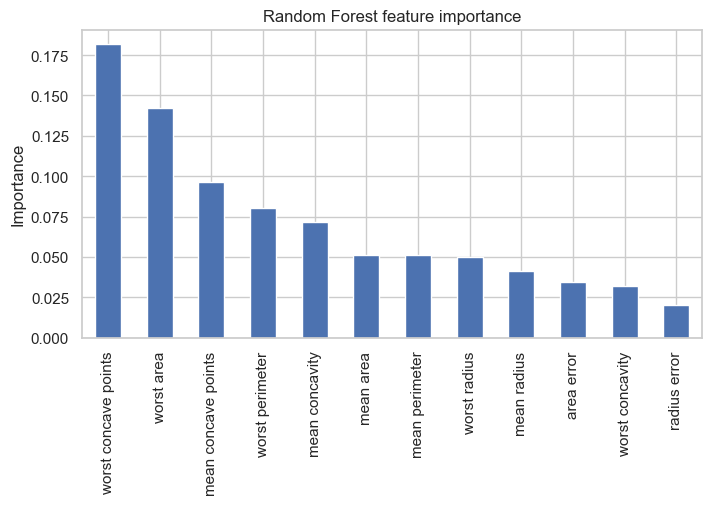

In [8]:
rf_rows=[]
for n in [10, 50, 100, 200]:
    model = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    row=evaluate_binary_model(f"RF n={n}", model, X_train, y_train, X_val, y_val)
    row["n_estimators"]=n
    rf_rows.append(row)
rf_df=pd.DataFrame(rf_rows)
display(rf_df[["n_estimators", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Runtime_sec"]])
plt.figure(figsize=(7,4))
plt.plot(rf_df["n_estimators"], rf_df["F1"], marker="o")
plt.title("Random Forest: n_estimators vs validation F1")
plt.xlabel("n_estimators"); plt.ylabel("F1")
plt.show()

for param, values in {"max_depth": [3,5,10,None], "max_features": ["sqrt", "log2", None], "min_samples_leaf": [1,5,10]}.items():
    rows=[]
    for v in values:
        kwargs={param: v}
        model=RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, **kwargs)
        row=evaluate_binary_model(f"RF {param}={v}", model, X_train, y_train, X_val, y_val)
        row[param]=str(v)
        rows.append(row)
    print("\n", param)
    display(pd.DataFrame(rows)[[param, "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]])

rf_best=RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=False).head(12).plot(kind="bar", figsize=(8,4), title="Random Forest feature importance")
plt.ylabel("Importance"); plt.show()

### Analytical interpretation

Random Forest performance usually improves quickly as trees are added and then stabilizes. A plateau means that adding more trees mainly increases computation. Depth and leaf-size results indicate how much complexity each individual tree should be allowed.

## AdaBoost

AdaBoost sequentially focuses on previously misclassified samples. It can reduce bias but may be sensitive to noise and outliers.

AdaBoost trains learners sequentially and increases attention to samples that were previously misclassified. It often works well with shallow trees, but because it focuses strongly on hard cases, noisy labels and outliers can mislead it.

Tree complexity is varied manually through depth or leaf-size parameters. Comparing training and validation scores shows whether the tree is too simple, reasonably balanced, or overfitting.

In [9]:
def make_adaboost(depth=1, n_estimators=50, learning_rate=1.0):
    base = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    try:
        return AdaBoostClassifier(estimator=base, n_estimators=n_estimators, learning_rate=learning_rate, random_state=RANDOM_STATE)
    except TypeError:
        return AdaBoostClassifier(base_estimator=base, n_estimators=n_estimators, learning_rate=learning_rate, random_state=RANDOM_STATE)

ada_rows=[]
for n in [25, 50, 100, 200]:
    model=make_adaboost(depth=1, n_estimators=n, learning_rate=1.0)
    row=evaluate_binary_model(f"AdaBoost n={n}", model, X_train, y_train, X_val, y_val)
    row["n_estimators"]=n
    ada_rows.append(row)
for lr in [0.03, 0.1, 0.5, 1.0]:
    model=make_adaboost(depth=1, n_estimators=100, learning_rate=lr)
    row=evaluate_binary_model(f"AdaBoost lr={lr}", model, X_train, y_train, X_val, y_val)
    row["learning_rate"]=lr
    ada_rows.append(row)
for depth in [1,2,3]:
    model=make_adaboost(depth=depth, n_estimators=100, learning_rate=0.5)
    row=evaluate_binary_model(f"AdaBoost depth={depth}", model, X_train, y_train, X_val, y_val)
    row["base_depth"]=depth
    ada_rows.append(row)
ada_df=pd.DataFrame(ada_rows)
display(ada_df[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Runtime_sec"]])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Runtime_sec
0,AdaBoost n=25,0.973684,0.972222,0.985915,0.979021,0.993449,0.194872
1,AdaBoost n=50,0.947368,0.933333,0.985915,0.958904,0.980347,0.287680
2,AdaBoost n=100,0.964912,0.958904,0.985915,0.972222,0.997052,0.829798
3,AdaBoost n=200,0.964912,0.958904,0.985915,0.972222,0.997380,1.200912
4,AdaBoost lr=0.03,0.956140,0.971429,0.957746,0.964539,0.984769,0.581647
5,AdaBoost lr=0.1,0.956140,0.958333,0.971831,0.965035,0.992139,0.550115
6,AdaBoost lr=0.5,0.947368,0.945205,0.971831,0.958333,0.989846,0.601473
7,AdaBoost lr=1.0,0.964912,0.958904,0.985915,0.972222,0.997052,0.597636
8,AdaBoost depth=1,0.947368,0.945205,0.971831,0.958333,0.989846,0.612496
9,AdaBoost depth=2,0.964912,0.946667,1.000000,0.972603,0.994432,0.941144


### Analytical interpretation

The tree experiments should show the classic complexity pattern: shallow trees underfit, while very deep trees often achieve high training performance with weaker validation behavior. Leaf-size constraints usually improve stability by preventing tiny, highly specific terminal regions.

## Gradient Boosting

Gradient boosting sequentially fits errors. `learning_rate`, `n_estimators`, `max_depth`, and `subsample` control speed, interaction complexity, and overfitting.

Gradient Boosting builds an additive sequence of weak learners. Each learner focuses on the remaining errors, so the ensemble can become very accurate. However, too much depth, too many estimators, or too large a learning rate can overfit.

Gradient Boosting settings are varied to study the trade-off between learning rate, number of estimators, and tree depth. This shows how sequential error correction can improve performance but also overfit.

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Runtime_sec
7,"GB lr=0.2, n=100",0.964912,0.958904,0.985915,0.972222,0.994432,1.031523
8,"GB lr=0.2, n=200",0.964912,0.958904,0.985915,0.972222,0.995414,1.752743
9,GB depth=1,0.964912,0.958904,0.985915,0.972222,0.991975,0.500231
4,"GB lr=0.1, n=100",0.964912,0.971831,0.971831,0.971831,0.993613,1.041046
5,"GB lr=0.1, n=200",0.964912,0.971831,0.971831,0.971831,0.994759,1.626178
10,GB depth=2,0.964912,0.971831,0.971831,0.971831,0.993613,0.760714
15,GB subsample=1.0,0.964912,0.971831,0.971831,0.971831,0.993613,0.845920
2,"GB lr=0.03, n=200",0.956140,0.958333,0.971831,0.965035,0.993285,1.777639
11,GB depth=3,0.956140,0.971429,0.957746,0.964539,0.992630,1.217934
12,GB depth=5,0.956140,0.985294,0.943662,0.964029,0.975106,1.818700


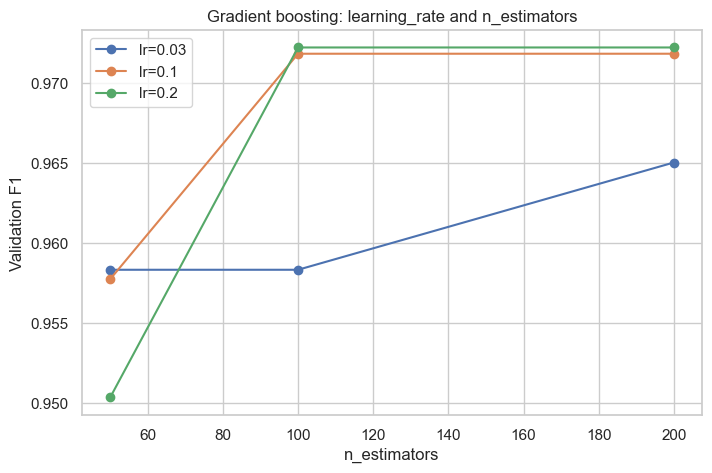

In [10]:
gb_rows=[]
for lr in [0.03,0.1,0.2]:
    for n in [50,100,200]:
        model=GradientBoostingClassifier(learning_rate=lr, n_estimators=n, max_depth=2, random_state=RANDOM_STATE)
        row=evaluate_binary_model(f"GB lr={lr}, n={n}", model, X_train, y_train, X_val, y_val)
        row["learning_rate"]=lr; row["n_estimators"]=n
        gb_rows.append(row)
for depth in [1,2,3,5]:
    model=GradientBoostingClassifier(learning_rate=0.1, n_estimators=100, max_depth=depth, random_state=RANDOM_STATE)
    row=evaluate_binary_model(f"GB depth={depth}", model, X_train, y_train, X_val, y_val)
    row["max_depth"]=depth
    gb_rows.append(row)
for sub in [0.5,0.8,1.0]:
    model=GradientBoostingClassifier(learning_rate=0.1, n_estimators=100, max_depth=2, subsample=sub, random_state=RANDOM_STATE)
    row=evaluate_binary_model(f"GB subsample={sub}", model, X_train, y_train, X_val, y_val)
    row["subsample"]=sub
    gb_rows.append(row)
gb_df=pd.DataFrame(gb_rows)
display(gb_df.sort_values("F1", ascending=False)[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Runtime_sec"]].head(15))

plt.figure(figsize=(8,5))
for lr, sub in gb_df.dropna(subset=["learning_rate", "n_estimators"]).groupby("learning_rate"):
    compact = sub.dropna(subset=["n_estimators"]).groupby("n_estimators")["F1"].max().reset_index()
    plt.plot(compact["n_estimators"], compact["F1"], marker="o", label=f"lr={lr}")
plt.title("Gradient boosting: learning_rate and n_estimators")
plt.xlabel("n_estimators"); plt.ylabel("Validation F1")
plt.legend(); plt.show()

### Analytical interpretation

Boosting results should be read through the learning-rate/estimator trade-off. Strong validation performance with controlled depth suggests useful sequential error correction; a growing train-validation gap suggests the ensemble is beginning to chase noise.

## Optional XGBoost

This section runs only if `xgboost` is installed. XGBoost is regularized gradient boosting with row and column subsampling options.

The optional boosted-tree library section runs only if the package is available. If it runs, compare the added flexibility and regularization controls with scikit-learn Gradient Boosting.

In [11]:
try:
    from xgboost import XGBClassifier
    xgb_rows=[]
    for lr in [0.03,0.1,0.2]:
        for depth in [2,3,5]:
            model=XGBClassifier(n_estimators=100, learning_rate=lr, max_depth=depth, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)
            row=evaluate_binary_model(f"XGB lr={lr}, depth={depth}", model, X_train, y_train, X_val, y_val)
            row["learning_rate"]=lr; row["max_depth"]=depth
            xgb_rows.append(row)
    xgb_df=pd.DataFrame(xgb_rows).sort_values("F1", ascending=False)
    display(xgb_df[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Runtime_sec"]])
except Exception as e:
    print("XGBoost section skipped. Install xgboost to run it. Error:", e)

XGBoost section skipped. Install xgboost to run it. Error: No module named 'xgboost'


### Analytical interpretation

If the optional model runs, compare whether its additional regularization and subsampling improve validation or test performance enough to justify the extra dependency and complexity.

## Optional LightGBM

This section runs only if `lightgbm` is installed. LightGBM uses leaf-wise growth; `num_leaves` is a major complexity control.

The optional boosted-tree library section runs only if the package is available. If it runs, compare the added flexibility and regularization controls with scikit-learn Gradient Boosting.

In [12]:
try:
    from lightgbm import LGBMClassifier
    lgb_rows=[]
    for leaves in [7,15,31,63]:
        for lr in [0.03,0.1]:
            model=LGBMClassifier(n_estimators=100, learning_rate=lr, num_leaves=leaves, max_depth=-1, random_state=RANDOM_STATE, verbose=-1)
            row=evaluate_binary_model(f"LGBM leaves={leaves}, lr={lr}", model, X_train, y_train, X_val, y_val)
            row["num_leaves"]=leaves; row["learning_rate"]=lr
            lgb_rows.append(row)
    lgb_df=pd.DataFrame(lgb_rows).sort_values("F1", ascending=False)
    display(lgb_df[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Runtime_sec"]])
except Exception as e:
    print("LightGBM section skipped. Install lightgbm to run it. Error:", e)

LightGBM section skipped. Install lightgbm to run it. Error: No module named 'lightgbm'


### Analytical interpretation

If the optional model runs, compare whether its additional regularization and subsampling improve validation or test performance enough to justify the extra dependency and complexity.

## Model comparison table

Tree complexity is varied manually through depth or leaf-size parameters. Comparing training and validation scores shows whether the tree is too simple, reasonably balanced, or overfitting.

In [13]:
final_models = {
    "Single deep tree": DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE),
    "Bagging": make_bagging(n_estimators=100),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "AdaBoost": make_adaboost(depth=1, n_estimators=100, learning_rate=0.5),
    "Gradient Boosting": GradientBoostingClassifier(learning_rate=0.1, n_estimators=100, max_depth=2, random_state=RANDOM_STATE),
}
rows=[]
for name, model in final_models.items():
    start=time.time(); model.fit(X_train, y_train); runtime=time.time()-start
    pred=model.predict(X_test)
    score=model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    row={"Model": name, "runtime_sec": runtime}
    row.update(binary_metrics(y_test, pred, score))
    rows.append(row)
final_df=pd.DataFrame(rows).sort_values("F1", ascending=False)
display(final_df)

,Model,runtime_sec,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,Random Forest,0.246897,0.947368,0.958333,0.958333,0.958333,0.991733,0.995124
3,Extra Trees,0.288567,0.947368,0.958333,0.958333,0.958333,0.994544,0.996743
4,AdaBoost,0.684770,0.947368,0.958333,0.958333,0.958333,0.985119,0.990381
5,Gradient Boosting,0.867225,0.938596,0.945205,0.958333,0.951724,0.991071,0.994773
1,Bagging,0.450995,0.938596,0.957746,0.944444,0.951049,0.993386,0.996143
0,Single deep tree,0.027629,0.903509,0.969231,0.875000,0.919708,0.913690,0.927024


### Analytical interpretation

The tree experiments should show the classic complexity pattern: shallow trees underfit, while very deep trees often achieve high training performance with weaker validation behavior. Leaf-size constraints usually improve stability by preventing tiny, highly specific terminal regions.

## Feature importance comparison

This cell performs the computational step described in the surrounding section. Read the resulting table or plot in terms of model behavior, not only in terms of the largest score.

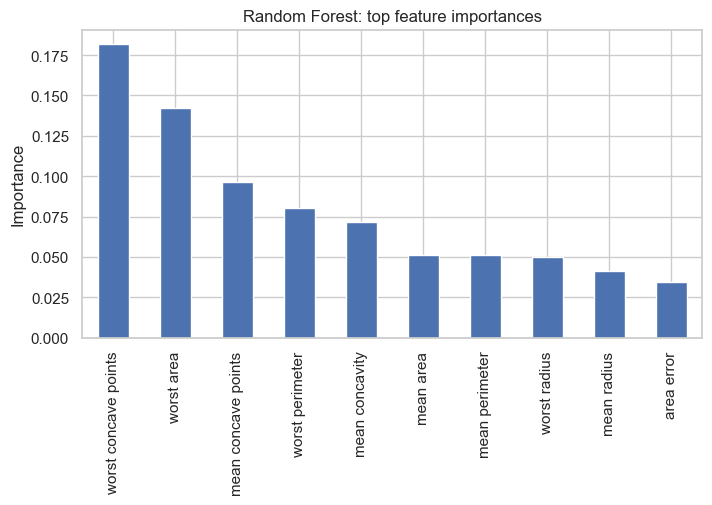

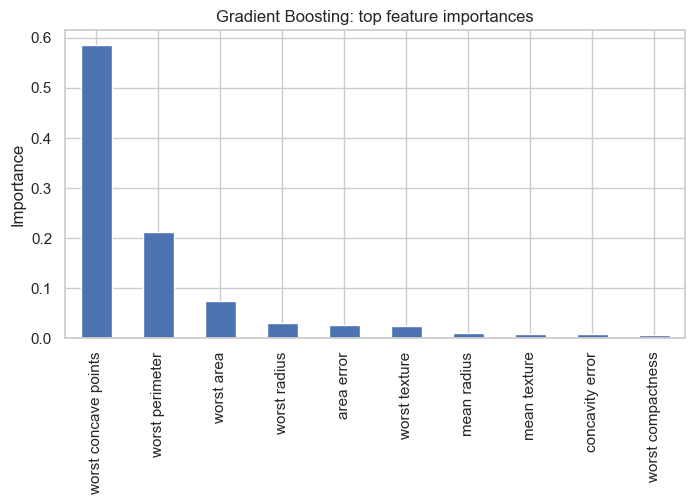

In [14]:
for name in ["Random Forest", "Gradient Boosting"]:
    model=final_models[name]
    if hasattr(model, "feature_importances_"):
        imp=pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
        imp.plot(kind="bar", figsize=(8,4), title=f"{name}: top feature importances")
        plt.ylabel("Importance"); plt.show()

### Analytical interpretation

Feature-importance plots allow comparison of which variables different ensembles emphasize. Agreement increases confidence in broad patterns, but importance still does not imply causality.

## Error analysis: Random Forest vs Gradient Boosting

This cell performs the computational step described in the surrounding section. Read the resulting table or plot in terms of model behavior, not only in terms of the largest score.

In [15]:
rf = final_models["Random Forest"]
gb = final_models["Gradient Boosting"]
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)
err_compare = pd.DataFrame({
    "true": y_test.values,
    "rf_pred": rf_pred,
    "gb_pred": gb_pred,
    "rf_error": rf_pred != y_test.values,
    "gb_error": gb_pred != y_test.values,
})
print("RF errors:", err_compare["rf_error"].sum())
print("GB errors:", err_compare["gb_error"].sum())
print("Common errors:", (err_compare["rf_error"] & err_compare["gb_error"]).sum())
display(err_compare[(err_compare["rf_error"] | err_compare["gb_error"])].head(15))

RF errors: 6
GB errors: 7
Common errors: 5


,true,rf_pred,gb_pred,rf_error,gb_error
3,1,0,0,True,True
25,1,0,1,True,False
35,0,1,1,True,True
53,0,1,1,True,True
65,0,1,1,True,True
66,1,1,0,False,True
84,0,0,1,False,True
110,1,0,0,True,True


### Analytical interpretation

The error-overlap table is valuable: Random Forest and Gradient Boosting share many mistakes, meaning their failures are partly systematic rather than completely model-specific.

## Bias-variance discussion

A single deep tree can overfit. Bagging and random forests reduce variance by averaging. Boosting can reduce bias through sequential correction, but may overfit if learner complexity, learning rate, or estimator count are not controlled.

## Limitations

- The dataset is small and clean compared with many real deployment settings.
- Optional XGBoost/LightGBM sections depend on installed packages.
- Feature importance is model-specific and not causal.
- Runtime conclusions depend on hardware.

## What we learned

This project covered weak vs strong learners, bagging, random forests, AdaBoost, gradient boosting, optional XGBoost and LightGBM, feature importance, runtime/performance tradeoffs, and ensemble error analysis.

## Possible extensions

Try calibrated probabilities, SHAP for tree ensembles, imbalanced ensemble methods, monotonic constraints, early stopping, and multi-dataset benchmarking.

## Additional analytical experiment: ensemble stability across random seeds

Ensembles contain randomness from bootstrap sampling, feature subsampling, and sometimes data ordering. A model that performs well across several random seeds is more reliable than a model that wins only once.

,mean,std,min,max
Model,,,,
Gradient Boosting,0.971831,0.000000,0.971831,0.971831
Random Forest,0.962109,0.005122,0.950355,0.965035


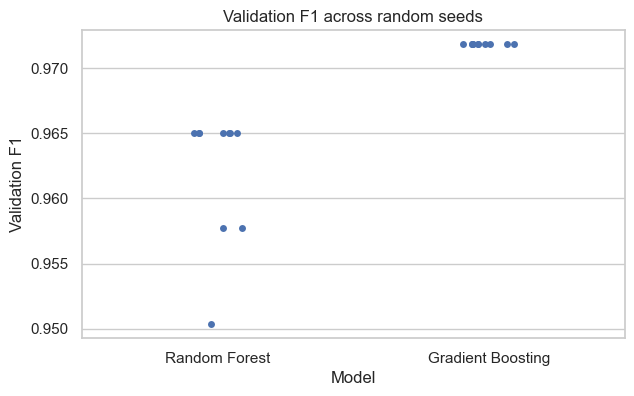

In [16]:
seed_rows = []
for seed in range(10):
    rf_seed = RandomForestClassifier(n_estimators=100, max_features="sqrt", random_state=seed, n_jobs=-1)
    gb_seed = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=seed)
    for name, model in [("Random Forest", rf_seed), ("Gradient Boosting", gb_seed)]:
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        seed_rows.append({"Model": name, "seed": seed, "val_F1": f1_score(y_val, pred)})
seed_df = pd.DataFrame(seed_rows)
display(seed_df.groupby("Model")["val_F1"].agg(["mean", "std", "min", "max"]))

plt.figure(figsize=(7,4))
sns.stripplot(data=seed_df, x="Model", y="val_F1", jitter=True)
plt.title("Validation F1 across random seeds")
plt.ylabel("Validation F1")
plt.show()


### How to interpret this added experiment
A small standard deviation means the ensemble is stable under randomness. If one method has slightly higher mean performance but much higher variability, a simpler or more stable method may be preferable in practice.